<a href="https://colab.research.google.com/github/Nur1160/nur1160/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tensorflow==2.15.0
!pip install -q scikit-learn matplotlib seaborn opencv-python-headless Pillow tqdm
print("✅ All libraries installed!")

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
✅ All libraries installed!


In [ ]:
import os, cv2, random, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from pathlib import Path
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import (
    VGG16, ResNet50, InceptionV3, EfficientNetB3,
    DenseNet121, MobileNetV2, Xception
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
from sklearn.model_selection import train_test_split

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"✅ TensorFlow: {tf.__version__}")
print(f"🖥️  GPU: {'Found ✅' if gpus else 'NOT FOUND ❌ — go to Runtime > Change runtime type > T4 GPU'}")
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("✅ All imports done!")

✅ TensorFlow: 2.20.0
🖥️  GPU: Found ✅
✅ All imports done!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ✏️ CHANGE THESE if your folder names are different
BASE_DIR        = '/content/drive/MyDrive/CASIA V 2.0'
AUTH_DIR        = os.path.join(BASE_DIR, 'Au')
TAMPERED_DIR    = os.path.join(BASE_DIR, 'Tp')
GROUNDTRUTH_DIR = os.path.join(BASE_DIR, 'CASIA 2 Groundtruth')

# Output folders (created automatically)
OUTPUT_DIR  = '/content/outputs'
MODELS_DIR  = os.path.join(OUTPUT_DIR, 'saved_models')
PLOTS_DIR   = os.path.join(OUTPUT_DIR, 'plots')
for d in [OUTPUT_DIR, MODELS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Verify
print("\n--- Checking your folders ---")
for name, path in [('Authentic (Au)', AUTH_DIR), ('Tampered (Tp)', TAMPERED_DIR)]:
    exists = os.path.isdir(path)
    count  = len(os.listdir(path)) if exists else 0
    print(f"{'✅' if exists else '❌ NOT FOUND'} {name}: {count} files  →  {path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Checking your folders ---


Authentic images : 0
Tampered images  : 0
Total            : 0

Class distribution:
Series([], Name: count, dtype: int64)


ValueError: 'explode' must be of length 'x', not 2

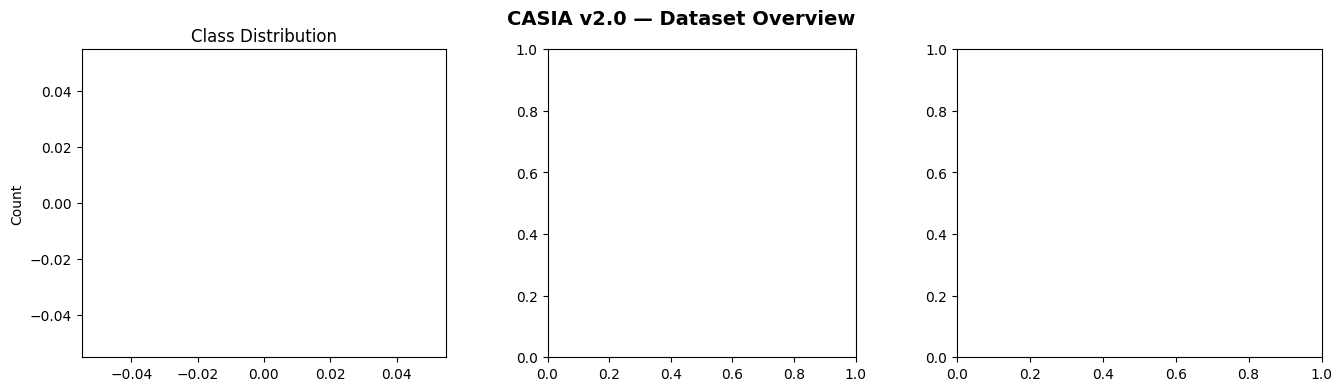

In [ ]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def collect_images(folder):
    paths = []
    for root, _, files in os.walk(folder):
        for f in files:
            if Path(f).suffix.lower() in IMG_EXTS:
                paths.append(os.path.join(root, f))
    return paths

auth_paths     = collect_images(AUTH_DIR)
tampered_paths = collect_images(TAMPERED_DIR)

print(f"Authentic images : {len(auth_paths):,}")
print(f"Tampered images  : {len(tampered_paths):,}")
print(f"Total            : {len(auth_paths) + len(tampered_paths):,}")

# Build dataframe
all_paths  = auth_paths + tampered_paths
all_labels = [0]*len(auth_paths) + [1]*len(tampered_paths)  # 0=Authentic, 1=Tampered
df = pd.DataFrame({'path': all_paths, 'label': all_labels})
df['class'] = df['label'].map({0: 'Authentic', 1: 'Tampered'})
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nClass distribution:")
print(df['class'].value_counts())

# --- Plot Overview ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CASIA v2.0 — Dataset Overview', fontsize=14, fontweight='bold')

counts = df['class'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+10,
                 f'{b.get_height():,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index,
            colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Class Proportion')

sizes = []
for p in random.sample(all_paths, min(200, len(all_paths))):
    try:
        img = Image.open(p)
        sizes.append(max(img.size))
    except: pass
axes[2].hist(sizes, bins=30, color='#3498db', edgecolor='black')
axes[2].set_title('Image Size Distribution'); axes[2].set_xlabel('Pixels')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Sample Images Grid ---
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Sample Images — Top: Authentic | Bottom: Tampered', fontsize=13, fontweight='bold')
for i, (paths, row_axes) in enumerate(zip([auth_paths, tampered_paths], axes)):
    for ax, p in zip(row_axes, random.sample(paths, 6)):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.axis('off')
        ax.set_title(['Auth','Tamp'][i], color=['green','red'][i], fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dataset loaded and visualized!")

In [ ]:
# --- Settings ---
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-4
FINE_TUNE_AT = 100

# --- Split: 70% train / 15% val / 15% test ---
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print(f"Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}")

# --- tf.data pipeline ---
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.image.random_hue(img, 0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(dataframe, augment_data=False, shuffle=False):
    paths  = dataframe['path'].values
    labels = dataframe['label'].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment_data=True,  shuffle=True)
val_ds   = make_dataset(val_df,   augment_data=False, shuffle=False)
test_ds  = make_dataset(test_df,  augment_data=False, shuffle=False)

print("✅ Data pipeline ready!")

In [ ]:
def add_head(base_model, name, dropout=0.5):
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout/2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return Model(inputs=base_model.input, outputs=out, name=name)

def build_custom_cnn():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inp
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.25)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x); x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x); x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return Model(inputs=inp, outputs=out, name='Custom_CNN')

def build_transfer(backbone_fn, name):
    base = backbone_fn(weights='imagenet', include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    return add_head(base, name)

MODEL_REGISTRY = {
    'Custom_CNN'    : build_custom_cnn,
    'VGG16'         : lambda: build_transfer(VGG16,          'VGG16'),
    'ResNet50'      : lambda: build_transfer(ResNet50,        'ResNet50'),
    'InceptionV3'   : lambda: build_transfer(InceptionV3,     'InceptionV3'),
    'EfficientNetB3': lambda: build_transfer(EfficientNetB3,  'EfficientNetB3'),
    'DenseNet121'   : lambda: build_transfer(DenseNet121,     'DenseNet121'),
    'MobileNetV2'   : lambda: build_transfer(MobileNetV2,     'MobileNetV2'),
    'Xception'      : lambda: build_transfer(Xception,        'Xception'),
}
print("✅ 8 models registered:", list(MODEL_REGISTRY.keys()))

In [ ]:
def compile_model(model, lr=LR):
    model.compile(
        optimizer=Adam(lr),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=7,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{MODELS_DIR}/{name}_best.h5',
                        monitor='val_accuracy', save_best_only=True, verbose=0)
    ]

all_histories  = {}
trained_models = {}

for model_name, build_fn in MODEL_REGISTRY.items():
    print(f"\n{'='*60}")
    print(f"  ▶ Training: {model_name}")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()
    model = build_fn()
    compile_model(model)

    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    all_histories[model_name]  = history
    trained_models[model_name] = model
    print(f"✅ {model_name} done!\n")

print("\n🎉 ALL 8 MODELS TRAINED!")

In [ ]:
def plot_training_curves(history, model_name):
    h = history.history
    epochs = range(1, len(h['loss']) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{model_name} — Training Curves', fontsize=15, fontweight='bold')

    pairs = [
        ('loss',      'val_loss',      'Loss',      '#e74c3c'),
        ('accuracy',  'val_accuracy',  'Accuracy',  '#2ecc71'),
        ('precision', 'val_precision', 'Precision', '#3498db'),
        ('recall',    'val_recall',    'Recall',    '#f39c12'),
        ('auc',       'val_auc',       'AUC',       '#9b59b6'),
    ]
    for ax, (tk, vk, title, color) in zip(axes.flat, pairs):
        train_vals = h.get(tk, [])
        val_vals   = h.get(vk, [])
        ax.plot(epochs, train_vals, color=color, lw=2, label='Train')
        ax.plot(epochs, val_vals,   color=color, lw=2, linestyle='--', alpha=0.7, label='Val')
        best = max(val_vals) if 'loss' not in vk else min(val_vals)
        ax.set_title(f"{title}  (best val: {best:.4f})", fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

    # F1 curve
    ax = axes.flat[-1]
    p  = np.array(h.get('precision',     []));  r  = np.array(h.get('recall',     []))
    vp = np.array(h.get('val_precision', []));  vr = np.array(h.get('val_recall', []))
    if len(p) and len(r):
        f1  = 2*p*r  / (p+r  + 1e-8)
        vf1 = 2*vp*vr/ (vp+vr+ 1e-8)
        ax.plot(epochs[:len(f1)],  f1,  color='#1abc9c', lw=2, label='Train F1')
        ax.plot(epochs[:len(vf1)], vf1, color='#1abc9c', lw=2, linestyle='--', alpha=0.7, label='Val F1')
        ax.set_title(f"F1-Score  (best val: {max(vf1):.4f})", fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/curves_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

for name, hist in all_histories.items():
    plot_training_curves(hist, name)

print("✅ All training curves saved!")

In [ ]:
# Collect predictions for all models
COLORS = ['#e74c3c','#3498db','#2ecc71','#f39c12',
          '#9b59b6','#1abc9c','#e67e22','#34495e']

results = {}

for model_name, model in trained_models.items():
    print(f"Evaluating {model_name}...", end=' ')
    y_true, y_prob = [], []
    for imgs, labels in test_ds:
        preds = model.predict(imgs, verbose=0).flatten()
        y_prob.extend(preds)
        y_true.extend(labels.numpy())
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    report = classification_report(y_true, y_pred,
                                   target_names=['Authentic','Tampered'],
                                   output_dict=True)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    results[model_name] = {
        'y_true': y_true, 'y_prob': y_prob, 'y_pred': y_pred,
        'report': report, 'fpr': fpr, 'tpr': tpr, 'auc': roc_auc,
        'cm': confusion_matrix(y_true, y_pred)
    }
    print(f"AUC={roc_auc:.4f} ✅")

# --- Plot confusion matrices ---
n    = len(results)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*4))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm      = r['cm']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['Authentic','Tampered'],
                yticklabels=['Authentic','Tampered'],
                ax=axes[i], linewidths=0.5,
                annot_kws={'size': 11, 'weight': 'bold'})
    for j in range(2):
        for k in range(2):
            axes[i].text(k+0.5, j+0.72, f'({cm[j,k]})',
                         ha='center', fontsize=8, color='gray')
    acc = r['report']['accuracy']
    axes[i].set_title(f"{name}\nAcc={acc:.3f}", fontweight='bold', fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# All ROC curves together
ax = axes[0]
ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
for (name, r), color in zip(results.items(), COLORS):
    ax.plot(r['fpr'], r['tpr'], color=color, lw=2,
            label=f"{name}  (AUC={r['auc']:.4f})")
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)

# AUC bar chart
ax2   = axes[1]
names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]
bars  = ax2.barh(names, aucs, color=COLORS, edgecolor='black')
for bar, val in zip(bars, aucs):
    ax2.text(val+0.003, bar.get_y()+bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold', fontsize=9)
ax2.set_xlim([min(aucs)-0.05, 1.02])
ax2.set_xlabel('AUC Score', fontsize=12)
ax2.set_title('AUC Score Comparison', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC-AUC curves saved!")

In [ ]:
rows_data = []
for name, r in results.items():
    rep = r['report']
    rows_data.append({
        'Model'    : name,
        'Accuracy' : rep['accuracy'],
        'Precision': rep['weighted avg']['precision'],
        'Recall'   : rep['weighted avg']['recall'],
        'F1-Score' : rep['weighted avg']['f1-score'],
        'AUC'      : r['auc'],
    })

summary_df = pd.DataFrame(rows_data).sort_values('F1-Score', ascending=False).set_index('Model')
pd.set_option('display.float_format', '{:.4f}'.format)

print("\n" + "="*60)
print("  MODEL PERFORMANCE SUMMARY (sorted by F1-Score)")
print("="*60)
print(summary_df.to_string())
summary_df.to_csv(f'{OUTPUT_DIR}/model_comparison.csv')

best_model_name = summary_df['F1-Score'].idxmax()
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy  : {summary_df.loc[best_model_name,'Accuracy']:.4f}")
print(f"   Precision : {summary_df.loc[best_model_name,'Precision']:.4f}")
print(f"   Recall    : {summary_df.loc[best_model_name,'Recall']:.4f}")
print(f"   F1-Score  : {summary_df.loc[best_model_name,'F1-Score']:.4f}")
print(f"   AUC       : {summary_df.loc[best_model_name,'AUC']:.4f}")

# Metrics grouped bar chart
x      = np.arange(len(summary_df))
width  = 0.15
metric_list   = ['Accuracy','Precision','Recall','F1-Score','AUC']
metric_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metric_list, metric_colors)):
    vals = summary_df[metric].values
    ax.bar(x + (i-2)*width, vals, width, label=metric,
           color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(summary_df.index, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Metrics — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Summary table saved!")

In [ ]:
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, (layers.Conv2D, layers.DepthwiseConv2D)):
            return layer.name
        if hasattr(layer, 'layers'):
            for sub in reversed(layer.layers):
                if isinstance(sub, (layers.Conv2D, layers.DepthwiseConv2D)):
                    return sub.name
    return None

def compute_gradcam(model, img_array, conv_layer_name):
    try:
        grad_model = Model(
            inputs=model.inputs,
            outputs=[model.get_layer(conv_layer_name).output, model.output]
        )
    except:
        for l in model.layers:
            if hasattr(l, 'layers'):
                try:
                    grad_model = Model(
                        inputs=model.inputs,
                        outputs=[l.get_layer(conv_layer_name).output, model.output]
                    )
                    break
                except: pass

    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, 0]

    grads    = tape.gradient(loss, conv_outputs)[0]
    pooled   = tf.reduce_mean(grads, axis=(0, 1))
    conv_out = conv_outputs[0]
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_rgb, heatmap, alpha=0.45):
    h = np.uint8(255 * heatmap)
    h_color = cv2.applyColorMap(
        cv2.resize(h, (img_rgb.shape[1], img_rgb.shape[0])), cv2.COLORMAP_JET)
    h_color = cv2.cvtColor(h_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_rgb, 1-alpha, h_color, alpha, 0)
    return overlay, h_color

print("✅ Grad-CAM functions ready!")

In [ ]:
# 3 authentic + 3 tampered samples
test_auth = test_df[test_df['label']==0].sample(3, random_state=SEED)
test_tamp = test_df[test_df['label']==1].sample(3, random_state=SEED)
gcam_df   = pd.concat([test_auth, test_tamp]).sample(frac=1, random_state=SEED)
gcam_paths  = gcam_df['path'].tolist()
gcam_labels = gcam_df['label'].tolist()

for model_name, model in trained_models.items():
    layer_name = get_last_conv_layer(model)
    print(f"\n{model_name} → conv layer: {layer_name}")
    if not layer_name:
        print("  ⚠️  Skipping — no conv layer found"); continue

    n = len(gcam_paths)
    fig, axes = plt.subplots(n, 4, figsize=(16, n*3.5))
    if n == 1: axes = axes[np.newaxis, :]
    fig.suptitle(f'Grad-CAM — {model_name}', fontsize=14, fontweight='bold')

    for col_ax, title in zip(axes[0], ['Original','Heatmap','Overlay','Prediction']):
        col_ax.set_title(title, fontweight='bold', fontsize=11)

    for idx, (path, true_label) in enumerate(zip(gcam_paths, gcam_labels)):
        orig     = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        orig_r   = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
        img_arr  = np.expand_dims(orig_r.astype(np.float32)/255.0, 0)
        pred_prob= model.predict(img_arr, verbose=0)[0][0]
        pred_cls = int(pred_prob >= 0.5)
        correct  = (pred_cls == int(true_label))

        heatmap  = compute_gradcam(model, img_arr, layer_name)
        overlay, heatmap_rgb = overlay_gradcam(orig_r, heatmap)

        axes[idx,0].imshow(orig_r);      axes[idx,0].axis('off')
        axes[idx,1].imshow(heatmap_rgb); axes[idx,1].axis('off')
        axes[idx,2].imshow(overlay);     axes[idx,2].axis('off')
        axes[idx,3].axis('off')

        color = '#27ae60' if correct else '#c0392b'
        info  = (
            f"True:  {'Authentic' if true_label==0 else 'Tampered'}\n"
            f"Pred:  {'Authentic' if pred_cls==0 else 'Tampered'}\n"
            f"Conf:  {pred_prob:.3f}\n"
            f"{'✔ CORRECT' if correct else '✘ WRONG'}"
        )
        axes[idx,3].text(0.5, 0.5, info, ha='center', va='center',
                         fontsize=11, color=color, fontweight='bold',
                         transform=axes[idx,3].transAxes,
                         bbox=dict(boxstyle='round,pad=0.4',
                                   facecolor='#ecf0f1', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/gradcam_{model_name}.png', dpi=130, bbox_inches='tight')
    plt.show()

print("\n✅ All Grad-CAM visualisations saved!")

In [ ]:
import shutil

DRIVE_OUT = '/content/drive/MyDrive/CASIA_Results'
os.makedirs(DRIVE_OUT, exist_ok=True)

# Copy plots and models
shutil.copytree(PLOTS_DIR,  f'{DRIVE_OUT}/plots',        dirs_exist_ok=True)
shutil.copytree(MODELS_DIR, f'{DRIVE_OUT}/saved_models', dirs_exist_ok=True)
shutil.copy(f'{OUTPUT_DIR}/model_comparison.csv',
            f'{DRIVE_OUT}/model_comparison.csv')

# Save best model
best_model = trained_models[best_model_name]
best_model.save(f'{DRIVE_OUT}/best_model_{best_model_name}')

print(f"✅ Everything saved to Google Drive!")
print(f"📁 Location: {DRIVE_OUT}")
print(f"\nSaved files:")
for f in sorted(Path(DRIVE_OUT).rglob('*')):
    if f.is_file():
        print(f"  📄 {f.relative_to(DRIVE_OUT)}")